# Data Exploration — Satellite Composites and Features

This notebook explores the satellite data layers, spectral features, and
change detection results produced by the pipeline.

**Covers:**
- Sentinel-2 RGB and NDVI composites
- Sentinel-1 SAR backscatter (VV/VH)
- FDP coffee probability layer
- Hansen forest loss overlay
- Hotspot GeoJSON structure
- Cross-AOI area comparison

No GEE connection required — all figures are loaded from `outputs/`.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd

REPO_ROOT = Path().resolve().parent
sys.path.insert(0, str(REPO_ROOT / 'src'))

from coffee_deforestation.config import PROJECT_ROOT
from coffee_deforestation.stats.schema import AOISummary

STATS_DIR = PROJECT_ROOT / 'outputs' / 'stats'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'
VECTORS_DIR = PROJECT_ROOT / 'outputs' / 'vectors'

def load_summary(aoi_id):
    with open(STATS_DIR / f'summary_{aoi_id}.json') as f:
        return AOISummary.model_validate(json.load(f))

AOI_IDS = ['lam_dong', 'huila', 'sul_de_minas']
summaries = {aoi: load_summary(aoi) for aoi in AOI_IDS if (STATS_DIR / f'summary_{aoi}.json').exists()}
print(f'Loaded {len(summaries)} summaries: {list(summaries.keys())}')

Loaded 3 summaries: ['lam_dong', 'huila', 'sul_de_minas']


## 1. Satellite composite panels

Each AOI generates 8 standard figures. Here we load and display the primary layers.

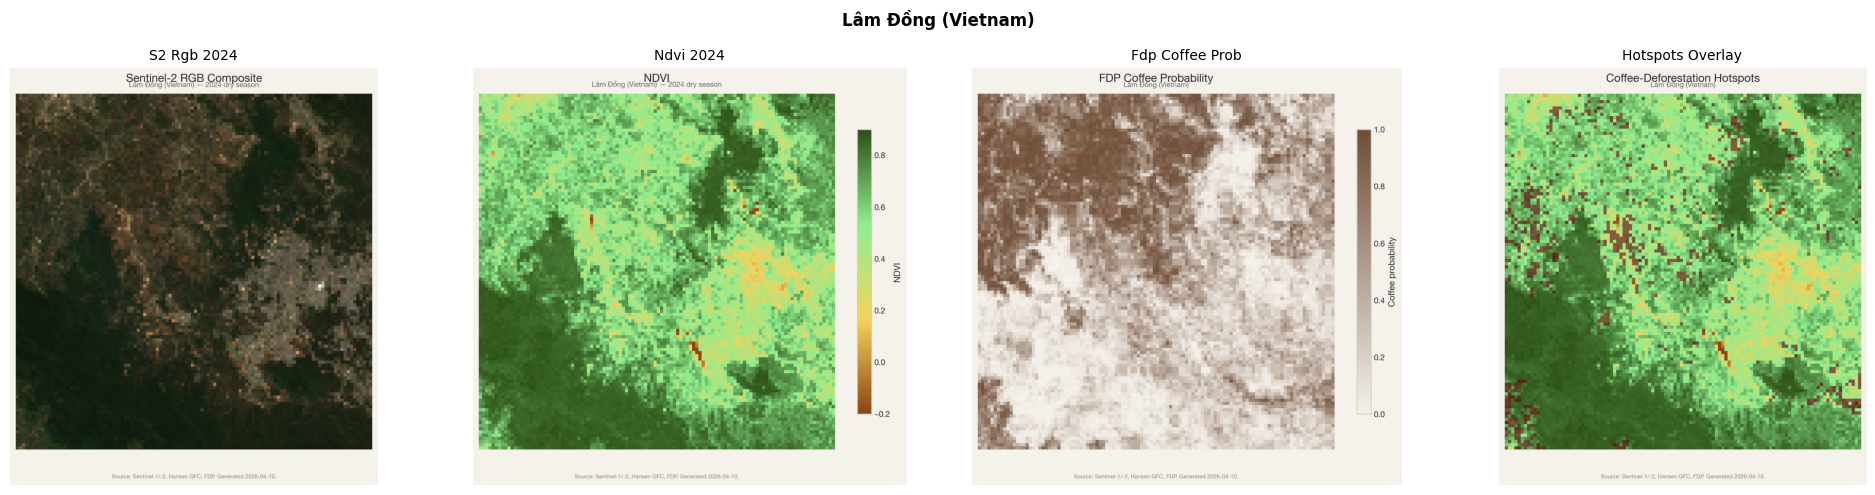

In [2]:
def show_layer_panel(aoi_id, layer_names):
    """Display multiple layer figures side by side for one AOI."""
    fig_dir = FIGURES_DIR / aoi_id
    available = [(name, fig_dir / f'{name}.png') for name in layer_names]
    available = [(n, p) for n, p in available if p.exists()]

    if not available:
        print(f'No figures found for {aoi_id}')
        return

    fig, axes = plt.subplots(1, len(available), figsize=(5 * len(available), 5))
    if len(available) == 1:
        axes = [axes]

    for ax, (name, path) in zip(axes, available):
        ax.imshow(mpimg.imread(str(path)))
        ax.set_title(name.replace('_', ' ').title(), fontsize=10)
        ax.axis('off')

    s = summaries[aoi_id]
    fig.suptitle(f'{s.metadata.name} ({s.metadata.country})', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Lam Dong — showcase AOI
show_layer_panel('lam_dong', ['s2_rgb_2024', 'ndvi_2024', 'fdp_coffee_prob', 'hotspots_overlay'])

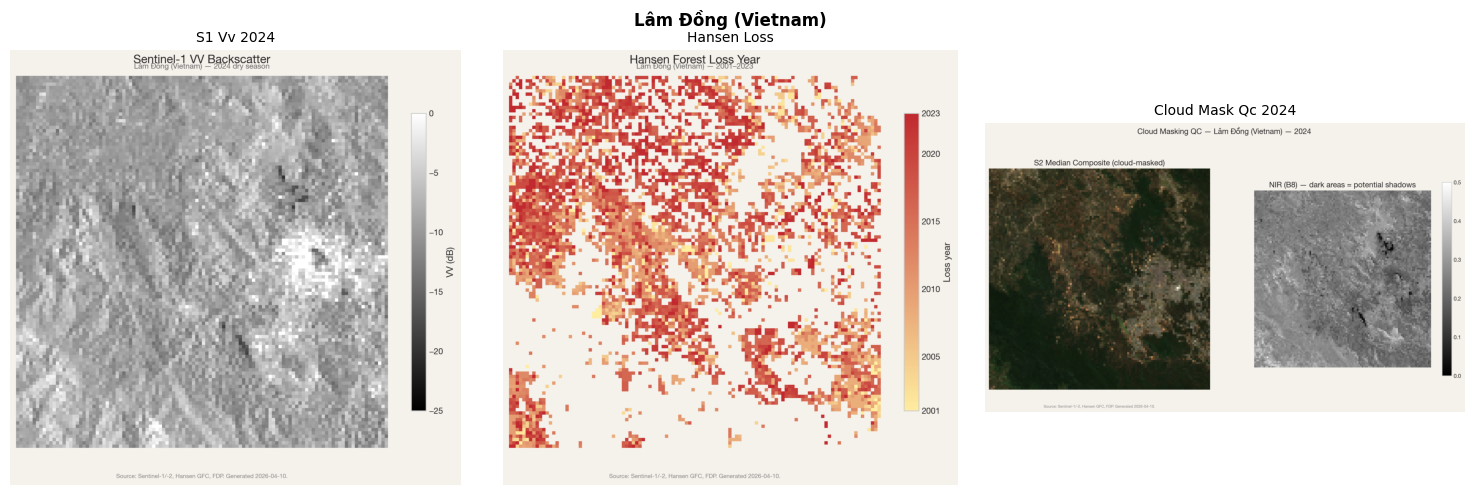

In [3]:
# SAR and Hansen layers
show_layer_panel('lam_dong', ['s1_vv_2024', 'hansen_loss', 'cloud_mask_qc_2024'])

## 2. Cross-AOI area comparison

Visual comparison of total affected area and hotspot counts across the three AOIs.

In [4]:
# Build comparison DataFrame from real pipeline outputs
rows = []
for aoi_id, s in summaries.items():
    cd = s.change_detection
    val = s.validation
    hist = s.historical
    rows.append({
        'AOI': s.metadata.name,
        'Role': s.metadata.role[:30] + '...' if len(s.metadata.role) > 30 else s.metadata.role,
        'Hotspots': cd.total_hotspots,
        'Area (ha)': round(cd.total_area_ha, 1),
        'Largest (ha)': round(cd.largest_hotspot_ha, 1),
        'Coffee %': round(val.coffee_fraction * 100, 1),
        'Forest-2000 %': round(val.forest_2000_fraction * 100, 1),
        'Coffee-on-Forest %': round(hist.coffee_on_former_forest_fraction * 100, 1) if hist else 'N/A',
    })

df = pd.DataFrame(rows)
df

,AOI,Role,Hotspots,Area (ha),Largest (ha),Coffee %,Forest-2000 %,Coffee-on-Forest %
0,Lâm Đồng,Primary showcase: known coffee...,5000,90539.7,22154.3,34.7,66.7,0.0
1,Huila,Generalization test: mountaino...,5000,41239.7,617.2,28.2,70.8,0.0
2,Sul de Minas,Negative control: stable plant...,5000,36269.6,413.1,38.4,18.0,0.0


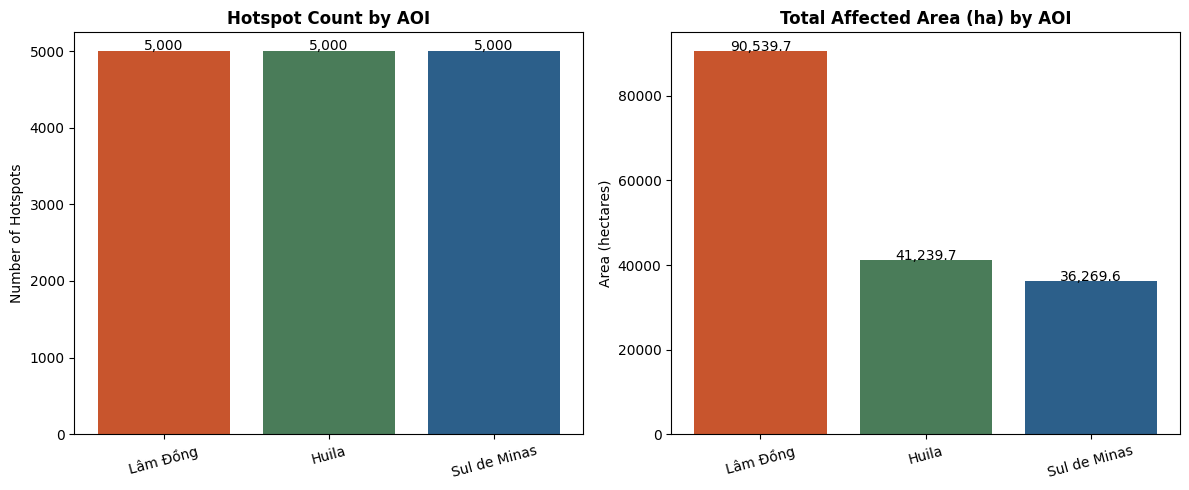

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#c8552d', '#4a7c59', '#2c5f8a']

# Hotspot count
axes[0].bar(df['AOI'], df['Hotspots'], color=colors)
axes[0].set_title('Hotspot Count by AOI', fontweight='bold')
axes[0].set_ylabel('Number of Hotspots')
for bar, val in zip(axes[0].patches, df['Hotspots']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:,}', ha='center', fontsize=10)

# Total area
axes[1].bar(df['AOI'], df['Area (ha)'], color=colors)
axes[1].set_title('Total Affected Area (ha) by AOI', fontweight='bold')
axes[1].set_ylabel('Area (hectares)')
for bar, val in zip(axes[1].patches, df['Area (ha)']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:,.1f}', ha='center', fontsize=10)

for ax in axes:
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 3. Hotspot GeoJSON structure

Each AOI produces a `hotspots_<aoi_id>.geojson` in `outputs/vectors/`.

In [6]:
geojson_path = VECTORS_DIR / 'hotspots_lam_dong.geojson'

if geojson_path.exists():
    with open(geojson_path) as f:
        geojson = json.load(f)

    features = geojson.get('features', [])
    print(f'Total features: {len(features)}')
    print(f'Feature type: {geojson["type"]}')
    print(f'\nFirst feature properties:')
    if features:
        props = features[0]['properties']
        for k, v in props.items():
            print(f'  {k}: {v}')
else:
    print(f'GeoJSON not found at {geojson_path}')
    print('Run: uv run scripts/run_all.py')

Total features: 5000
Feature type: FeatureCollection

First feature properties:
  hotspot_id: lam_dong_h001
  aoi_id: lam_dong
  area_ha: 22154.3
  centroid_lon: 107.885479
  centroid_lat: 12.001547
  rank: 1
  loss_year: 2011


## 4. Hotspot area distribution

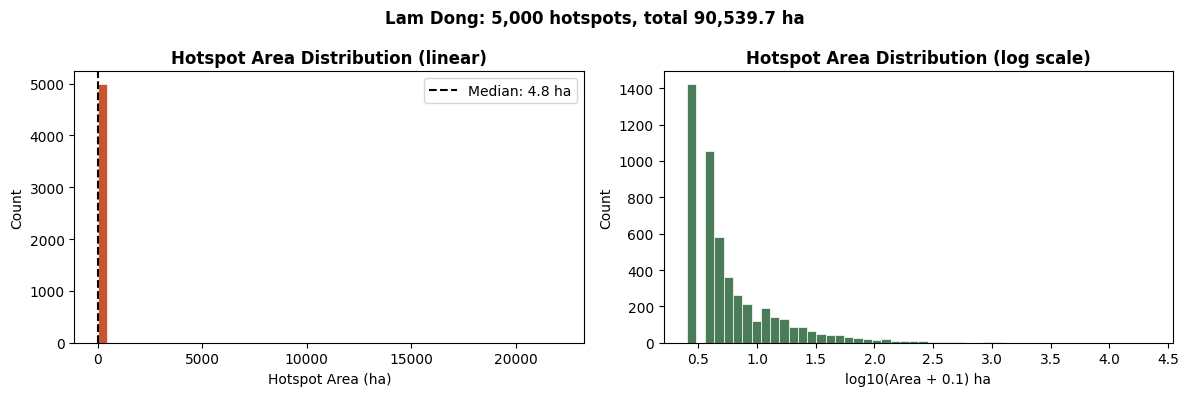


Area statistics:
  Min: 2.42 ha
  Median: 4.83 ha
  Mean: 18.11 ha
  Max: 22154.30 ha
  >10 ha: 990 (19.8%)
  >30 ha: 316 (6.3%)


In [7]:
if geojson_path.exists():
    areas = [f['properties']['area_ha'] for f in features if 'area_ha' in f['properties']]
    areas = np.array(areas)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Linear scale histogram
    axes[0].hist(areas, bins=50, color='#c8552d', edgecolor='white', linewidth=0.5)
    axes[0].set_xlabel('Hotspot Area (ha)')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Hotspot Area Distribution (linear)', fontweight='bold')
    axes[0].axvline(np.median(areas), color='k', linestyle='--', label=f'Median: {np.median(areas):.1f} ha')
    axes[0].legend()

    # Log scale
    axes[1].hist(np.log10(areas + 0.1), bins=50, color='#4a7c59', edgecolor='white', linewidth=0.5)
    axes[1].set_xlabel('log10(Area + 0.1) ha')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Hotspot Area Distribution (log scale)', fontweight='bold')

    plt.suptitle(f'Lam Dong: {len(areas):,} hotspots, total {areas.sum():,.1f} ha', fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f'\nArea statistics:')
    print(f'  Min: {areas.min():.2f} ha')
    print(f'  Median: {np.median(areas):.2f} ha')
    print(f'  Mean: {areas.mean():.2f} ha')
    print(f'  Max: {areas.max():.2f} ha')
    print(f'  >10 ha: {(areas > 10).sum()} ({(areas > 10).mean()*100:.1f}%)')
    print(f'  >30 ha: {(areas > 30).sum()} ({(areas > 30).mean()*100:.1f}%)')

## 5. Feature correlation (Lam Dong)

The pipeline generates a feature correlation heatmap during the run.

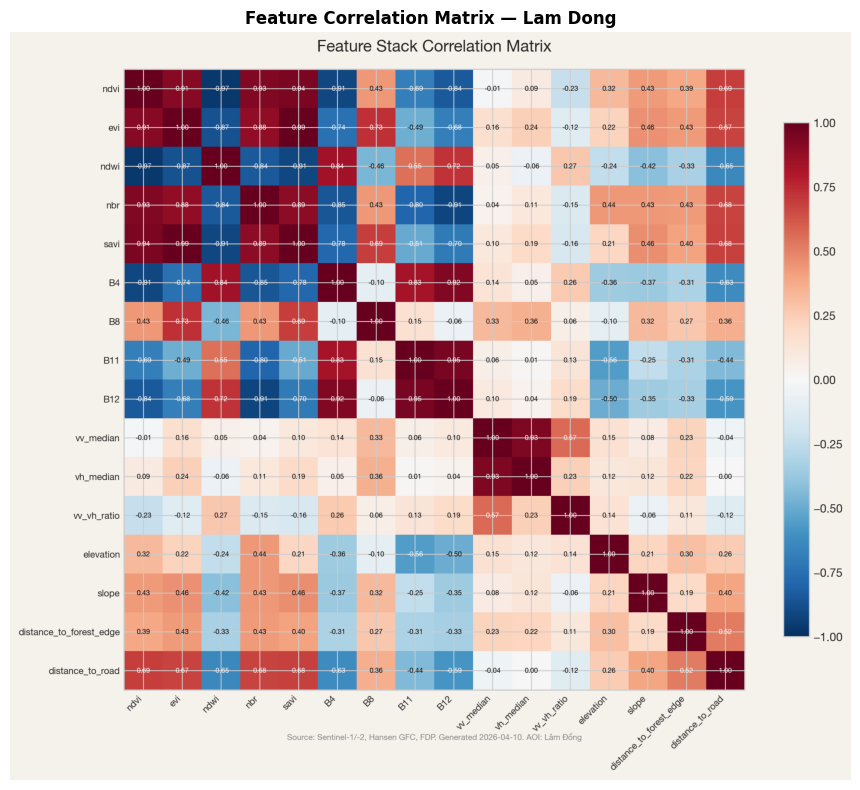

In [8]:
corr_path = FIGURES_DIR / 'lam_dong' / 'feature_correlation.png'
if corr_path.exists():
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(mpimg.imread(str(corr_path)))
    ax.axis('off')
    ax.set_title('Feature Correlation Matrix — Lam Dong', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print(f'Correlation figure not found. Run the pipeline first.')

## 6. Interactive folium map

Open the interactive map directly in this notebook.

In [9]:
from IPython.display import IFrame

map_path = PROJECT_ROOT / 'outputs' / 'maps' / 'hotspots_lam_dong.html'

if map_path.exists():
    IFrame(src=str(map_path), width='100%', height=500)
else:
    print(f'Interactive map not found at {map_path}')
    print('Run: uv run scripts/run_all.py')

Interactive map not found at /Users/workpieces/Code/coffee-deforestation/outputs/maps/hotspots_lam_dong.html
Run: uv run scripts/run_all.py


## 7. Geographic expansion opportunities

A note on extending coverage — see the `DECISIONS.md` geographic expansion section for context.

In [10]:
# Candidate expansion regions (from DECISIONS.md / project notes)
expansion_candidates = [
    {'region': 'Sidama, Ethiopia', 'coffee_type': 'Wild Arabica', 'estimated_deforestation': 'Moderate'},
    {'region': 'Antioquia, Colombia', 'coffee_type': 'Arabica', 'estimated_deforestation': 'High'},
    {'region': 'Minas Gerais North Belt, Brazil', 'coffee_type': 'Arabica', 'estimated_deforestation': 'Low'},
    {'region': 'Sumatra (Aceh), Indonesia', 'coffee_type': 'Robusta/Arabica', 'estimated_deforestation': 'High'},
    {'region': 'Additional patches around lam_dong', 'coffee_type': 'Robusta', 'estimated_deforestation': 'High'},
    {'region': 'Additional patches around huila', 'coffee_type': 'Arabica', 'estimated_deforestation': 'Moderate'},
]
pd.DataFrame(expansion_candidates)

,region,coffee_type,estimated_deforestation
0,"Sidama, Ethiopia",Wild Arabica,Moderate
1,"Antioquia, Colombia",Arabica,High
2,"Minas Gerais North Belt, Brazil",Arabica,Low
3,"Sumatra (Aceh), Indonesia",Robusta/Arabica,High
4,Additional patches around lam_dong,Robusta,High
5,Additional patches around huila,Arabica,Moderate
